In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn import preprocessing
from sklearn.model_selection import train_test_split    

In [77]:
df = pd.read_csv('data.csv')
print(df.head())

   Age    Income  Loan_Amount  Credit_Score Employment_Type  Loan_Approved
0   59   77761.0       417505           337        Salaried              0
1   49  141178.0       328226           487        Salaried              0
2   35   56368.0       312805           356   Self-Employed              0
3   28   26783.0       218484           319        Salaried              0
4   41  131530.0       315064           572   Self-Employed              0


In [78]:

df.columns.tolist()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              1000 non-null   int64  
 1   Income           950 non-null    float64
 2   Loan_Amount      1000 non-null   int64  
 3   Credit_Score     1000 non-null   int64  
 4   Employment_Type  950 non-null    object 
 5   Loan_Approved    1000 non-null   int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB


,Age,Income,Loan_Amount,Credit_Score,Loan_Approved
count,1000.000000,950.000000,1000.000000,1000.000000,1000.000000
mean,40.445000,84881.753684,270051.753000,610.381000,0.315000
std,11.499183,37717.819324,128863.845332,174.696974,0.464748
min,21.000000,20060.000000,51969.000000,300.000000,0.000000
25%,30.000000,51909.000000,160877.250000,460.000000,0.000000
50%,41.000000,83551.500000,266606.500000,612.000000,0.000000
75%,50.000000,116955.750000,383224.500000,764.000000,1.000000
max,59.000000,149972.000000,499370.000000,898.000000,1.000000


In [79]:
df.isnull().sum()

Age                 0
Income             50
Loan_Amount         0
Credit_Score        0
Employment_Type    50
Loan_Approved       0
dtype: int64

In [80]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Income'] = df['Income'].fillna(df['Income'].mean())
df['Loan_Amount'] = df['Loan_Amount'].fillna(df['Loan_Amount'].mean())
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,Salaried,0
1,49,141178.0,328226,487,Salaried,0
2,35,56368.0,312805,356,Self-Employed,0
3,28,26783.0,218484,319,Salaried,0
4,41,131530.0,315064,572,Self-Employed,0


In [81]:
len(df)

1000

In [82]:
df['Employment_Type'].value_counts()    
df['Employment_Type'] = df['Employment_Type'].fillna(df['Employment_Type'].mode()[0])
df.isnull().sum()

Age                0
Income             0
Loan_Amount        0
Credit_Score       0
Employment_Type    0
Loan_Approved      0
dtype: int64

In [83]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Employment_Type'] = le.fit_transform(df['Employment_Type']) 
df.head()   

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,0,0
1,49,141178.0,328226,487,0,0
2,35,56368.0,312805,356,1,0
3,28,26783.0,218484,319,0,0
4,41,131530.0,315064,572,1,0


In [84]:
x = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']  
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=100000000000000000000000)    
model.fit(x_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100000000000000000000000
,multi_class,'deprecated'


In [85]:
y_pred = model.predict(x_test)  
print(y_pred)

[1 0 0 1 1 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 1 0
 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0
 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1 1
 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0
 0 0 1 1 1 0 0 0 0 1 0 1 0 0 1]


In [86]:
y_test

521    1
737    0
740    0
660    1
411    1
      ..
408    1
332    1
208    0
613    0
78     0
Name: Loan_Approved, Length: 200, dtype: int64

In [87]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       135
           1       0.70      0.62      0.66        65

    accuracy                           0.79       200
   macro avg       0.76      0.74      0.75       200
weighted avg       0.79      0.79      0.79       200



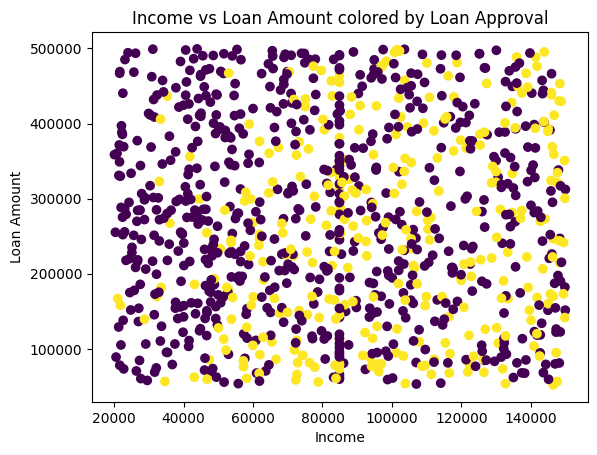

In [88]:
plt.scatter(df['Income'], df['Loan_Amount'], c=df['Loan_Approved'])
plt.xlabel('Income')        
plt.ylabel('Loan Amount')
plt.title('Income vs Loan Amount colored by Loan Approval')     
plt.show()  #scatter plot is used relationship between two numerical variables  


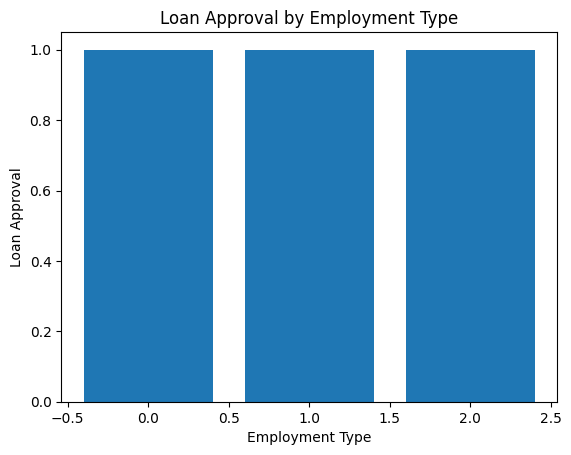

In [89]:
plt.bar(df['Employment_Type'], df['Loan_Approved'])
plt.xlabel('Employment Type')           
plt.ylabel('Loan Approval')
plt.title('Loan Approval by Employment Type')
plt.show() #bar plot is used to compare categorical variable with numerical variable and it is used to compare the frequency of categories in a categorical variable.

In [90]:
import joblib
joblib.dump(model, 'loan_approval_model.pkl')


['loan_approval_model.pkl']